<a href="https://colab.research.google.com/github/SvetlanaKhizhnyak/MMO/blob/main/%D0%9C%D0%9C%D0%9E_%D0%A0%D0%9A1_%D0%A5%D0%B8%D0%B6%D0%BD%D1%8F%D0%BA_%D0%98%D0%A35_23%D0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Хижняк Светлана, ИУ5-23М, ММО АСОИУ, Рубежный контроль №1
**Номер задачи №1 (Задача №11)**

Для набора данных проведите устранение пропусков для одного (произвольного) категориального признака с использованием метода заполнения отдельной категорией для пропущенных значений.

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

def impute_column(dataset, column, strategy_param, fill_value_param=None):
    temp_data = dataset[[column]].values
    size = temp_data.shape[0]

    imputer = SimpleImputer(strategy=strategy_param,
                            fill_value=fill_value_param)
    imputed_data = imputer.fit_transform(temp_data)

    # Возвращаем данные, приведенные к одномерному виду, и доп. параметры
    return imputed_data.reshape((size,)), imputer.statistics_, imputer.indicator_

# Создаем набор данных
data = {
    'Car_ID': [1, 2, 3, 4, 5],
    'Color': ['Red', 'Blue', np.nan, 'Green', np.nan],
    'Price': [20000, 15000, 18000, 22000, 19000]
}
df = pd.DataFrame(data)

Создаем копию данных для обработки

In [2]:
# Список категориальных колонок
cat_cols = ['Color']

# Создаем рабочую копию датасета
df_cat_na = df[cat_cols].copy()

print("Пропуски до обработки:")
print(df_cat_na.isnull().sum())

Пропуски до обработки:
Color    2
dtype: int64


In [3]:
# Применяем функцию
color_cat_na_temp, _, _ = impute_column(df_cat_na, 'Color', 'constant', fill_value_param='NA')

# Записываем результат обратно в таблицу
df_cat_na['Color'] = color_cat_na_temp

print("Результат заполнения:")
print(df_cat_na)

Результат заполнения:
   Color
0    Red
1   Blue
2     NA
3  Green
4     NA


Убедимся, что пропуски исчезли и появилась новая категория 'NA'.

In [4]:
print("Пропуски после обработки:", df_cat_na['Color'].isnull().sum())
print("\nУникальные значения в колонке Color:")
print(df_cat_na['Color'].value_counts())

Пропуски после обработки: 0

Уникальные значения в колонке Color:
Color
NA       2
Red      1
Blue     1
Green    1
Name: count, dtype: int64


In [6]:
# Объединяем исходные данные с обновленной колонкой
df_final = df.copy()
df_final['Color'] = df_cat_na['Color']

print("Финальный вид таблицы:")
print(df_final)

Финальный вид таблицы:
   Car_ID  Color  Price
0       1    Red  20000
1       2   Blue  15000
2       3     NA  18000
3       4  Green  22000
4       5     NA  19000


# Доп. задание
Для произвольной колонки данных построить график "Ящик с усами (boxplot)"

Построим график «Ящик с усами» для числового признака, чтобы оценить разброс значений и выявить потенциальные выбросы.

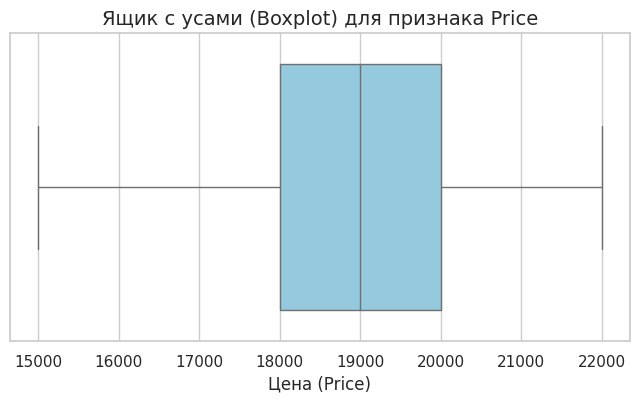

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Строим boxplot для колонки 'Price'
sns.boxplot(x=df_final['Price'], color='skyblue')
plt.title('Ящик с усами (Boxplot) для признака Price', fontsize=14)
plt.xlabel('Цена (Price)', fontsize=12)
plt.show()

# **Номер задачи №2 (Задача №31)**

Для набора данных проведите процедуру отбора признаков (feature selection). Используйте метод обертывания (wrapper method), прямой алгоритм (sequential forward selection).

In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

# Создаем датасет (100 строк, 6 признаков, из которых 4 информативных)
X_data, y_data = make_classification(
    n_samples=100,
    n_features=6,
    n_informative=4,
    n_redundant=2,
    random_state=42
)

# Превратим данные в DataFrame для наглядности
feature_names = [f'Feature_{i+1}' for i in range(X_data.shape[1])]
df_features = pd.DataFrame(X_data, columns=feature_names)
df_features['Target'] = y_data

print("Исходный набор данных (первые 5 строк):")
display(df_features.head())

Исходный набор данных (первые 5 строк):


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Target
0,-0.023737,-0.557501,0.709269,-0.275778,2.014873,-0.316782,1
1,-1.232940,-1.664769,0.944708,-1.016075,1.711619,1.746762,0
2,0.522053,-0.783525,0.735467,-0.881509,-0.536290,-0.669132,0
3,0.213063,-0.139386,0.105164,-1.018753,1.553322,-0.082202,1
4,-0.166002,0.497125,-0.406689,0.661715,-0.175963,0.155513,1


Зададим модель, на основе которой будет оцениваться качество (логистическая регрессия), и инициализируем прямой алгоритм отбора.

Настроим Sequential Feature Selector для отбора лучшего подмножества признаков. Зададим поиск вперед, оставим 3 наиболее значимых признака.

In [9]:
# Базовая модель для оценки признаков
model = LogisticRegression(solver='liblinear')

# Инициализируем прямой алгоритм отбора (Forward Selection)
sfs = SequentialFeatureSelector(
    estimator=model,
    n_features_to_select=3,
    direction='forward',
    scoring='accuracy',
    cv=5 # Кросс-валидация по 5 блокам
)

print("Объект SFS создан.")

Объект SFS создан.



Запускаем процесс обучения SFS, чтобы алгоритм выбрал наиболее полезные признаки

In [10]:
# Обучаем SFS
sfs.fit(X_data, y_data)

# Получаем маску выбранных признаков (True / False)
selected_mask = sfs.get_support()

# Выводим названия отобранных признаков
selected_features = np.array(feature_names)[selected_mask]

print("Отобранные признаки с использованием SFS:")
print(list(selected_features))

Отобранные признаки с использованием SFS:
[np.str_('Feature_2'), np.str_('Feature_3'), np.str_('Feature_4')]


Применяем полученную маску, чтобы оставить в датасете только отобранные признаки.

In [11]:
# Уменьшаем размерность массива до отобранных признаков
X_selected = sfs.transform(X_data)

# Создаем новый DataFrame с отобранными признаками для дальнейшего обучения
df_selected = pd.DataFrame(X_selected, columns=selected_features)
df_selected['Target'] = y_data

print("Датасет после отбора признаков:")
display(df_selected.head())

Датасет после отбора признаков:


,Feature_2,Feature_3,Feature_4,Target
0,-0.557501,0.709269,-0.275778,1
1,-1.664769,0.944708,-1.016075,0
2,-0.783525,0.735467,-0.881509,0
3,-0.139386,0.105164,-1.018753,1
4,0.497125,-0.406689,0.661715,1
